
# Data Cleaning and Preprocessing for City_Day dataset


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("/content/sample_data/city_day.csv")
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [7]:
print("Shape:", df.shape)

Shape: (29531, 16)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


In [9]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,4598
PM10,11140
NO,3582
NO2,3585
NOx,4185
NH3,10328
CO,2059
SO2,3854


In [10]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

,0
Xylene,61.322001
PM10,37.723071
NH3,34.973418
Toluene,27.229014
Benzene,19.041008
AQI,15.851139
AQI_Bucket,15.851139
PM2.5,15.570079
NOx,14.171549
O3,13.619586


In [11]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000


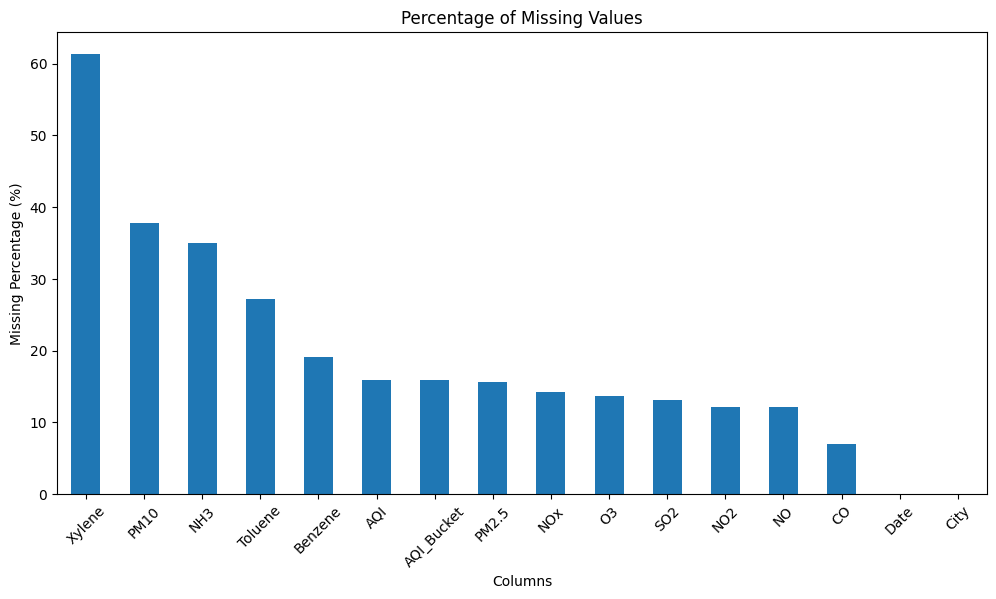

In [12]:
import matplotlib.pyplot as plt

missing_percent = (df.isnull().sum()/len(df))*100
missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(12,6))
missing_percent.plot(kind='bar')

plt.title('Percentage of Missing Values')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Columns')

plt.xticks(rotation=45)
plt.show()

In [13]:
# checking whether AQI and AQI_Bucket missing togather
df[df['AQI'].isnull()][['AQI', 'AQI_Bucket']].head(10)

,AQI,AQI_Bucket
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,NaN,NaN


The Above Results shows that the Empty values of AQI and AQI_Bucket are correspondent to each other.

In [15]:
# rows having multiple missing values
df['Missing_Count'] = df.isnull().sum(axis=1)
df['Missing_Count'].value_counts().sort_index()

,count
Missing_Count,
0,6236
1,5227
2,7261
3,3514
4,1669
5,1374
6,531
7,273
8,231


it means:
row 0 has 6326 missing values.

In [20]:
df.shape

(29531, 17)

In [21]:
df[df['Missing_Count'] == 14].head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Missing_Count
56,Ahmedabad,2015-02-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
57,Ahmedabad,2015-02-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
58,Ahmedabad,2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
64,Ahmedabad,2015-03-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
262,Ahmedabad,2015-09-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14


In [28]:
# checking how many rows have more than 10 missing values
total_missing_count = (df['Missing_Count'] > 10).sum()
total_missing_count

np.int64(1860)

In [29]:
total_rows = len(df)
percentage_incomplete = total_missing_count/total_rows * 100
percentage_incomplete

np.float64(6.298466018759948)

Which means around 6-6.2% dataset is incomplete

In [23]:
df[df['Missing_Count'] == 14].head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Missing_Count
56,Ahmedabad,2015-02-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
57,Ahmedabad,2015-02-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
58,Ahmedabad,2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
64,Ahmedabad,2015-03-06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14
262,Ahmedabad,2015-09-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14


In [30]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Missing_Count
count,24933.000000,18391.000000,25949.000000,25946.000000,25346.000000,19203.000000,27472.000000,25677.000000,25509.000000,23908.000000,21490.000000,11422.000000,24850.000000,29531.000000
mean,67.450578,118.127103,17.574730,28.560659,32.309123,23.483476,2.248598,14.531977,34.491430,3.280840,8.700972,3.070128,166.463581,2.996444
std,64.661449,90.605110,22.785846,24.474746,31.646011,25.684275,6.962884,18.133775,21.694928,15.811136,19.969164,6.323247,140.696585,3.525201
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,0.000000,0.000000,0.000000,13.000000,0.000000
25%,28.820000,56.255000,5.630000,11.750000,12.820000,8.580000,0.510000,5.670000,18.860000,0.120000,0.600000,0.140000,81.000000,1.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,1.070000,2.970000,0.980000,118.000000,2.000000
75%,80.590000,149.745000,19.950000,37.620000,40.127500,30.020000,1.450000,15.220000,45.570000,3.080000,9.150000,3.350000,208.000000,3.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,455.030000,454.850000,170.370000,2049.000000,14.000000


Data is right-skewed (large values pulling the average upward).
and Count != Total Rows

In [31]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73
Benzene,23908.0,3.280840,15.811136,0.00,0.120,1.07,3.0800,455.03


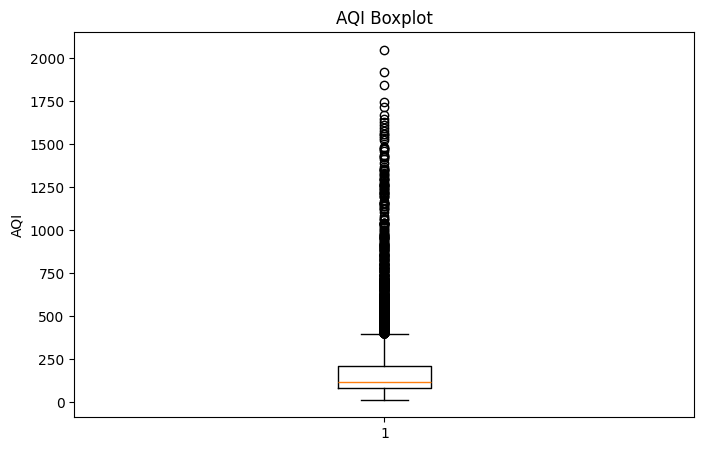

In [33]:
df['AQI_backup'] = df['AQI'].copy()
plt.figure(figsize=(8,5))
plt.boxplot(df['AQI_backup'].dropna())

plt.title('AQI Boxplot')
plt.ylabel('AQI')
plt.show()

Here we have created a backup AQI column before dropping the actual column so that we can preserve the actual.

In [45]:
Q1 = df['AQI'].quantile(0.25)
Q3 = df['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Bound:", upper_bound)

Q1: 81.0
Q3: 208.0
IQR: 127.0
Upper Bound: 398.5


In [46]:
Q1 = df['AQI'].quantile(0.25)
Q3 = df['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['AQI'] < lower_bound) |
    (df['AQI'] > upper_bound)
]

print("Upper Bound:", upper_bound)
print("Number of AQI Outliers:", len(outliers))

Upper Bound: 398.5
Number of AQI Outliers: 1358


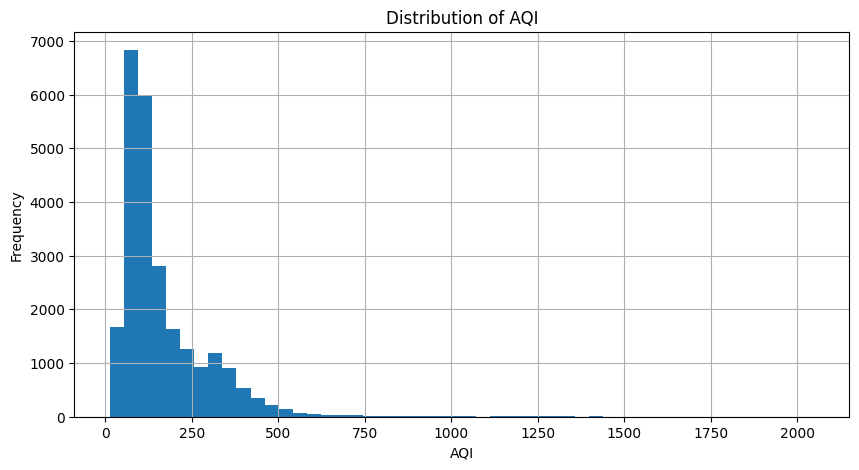

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df['AQI'].hist(bins=50)

plt.title('Distribution of AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')

plt.show()

In [42]:
df[['AQI_backup']].shape

(29531, 1)

In [43]:
# dropping the null values from AQI
df = df.dropna(subset=['AQI'])
df[['AQI']].shape

(24850, 1)

In [48]:
df.drop(columns=['AQI_backup'], inplace=True)

/tmp/ipykernel_1917/3871154560.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=['AQI_backup'], inplace=True)


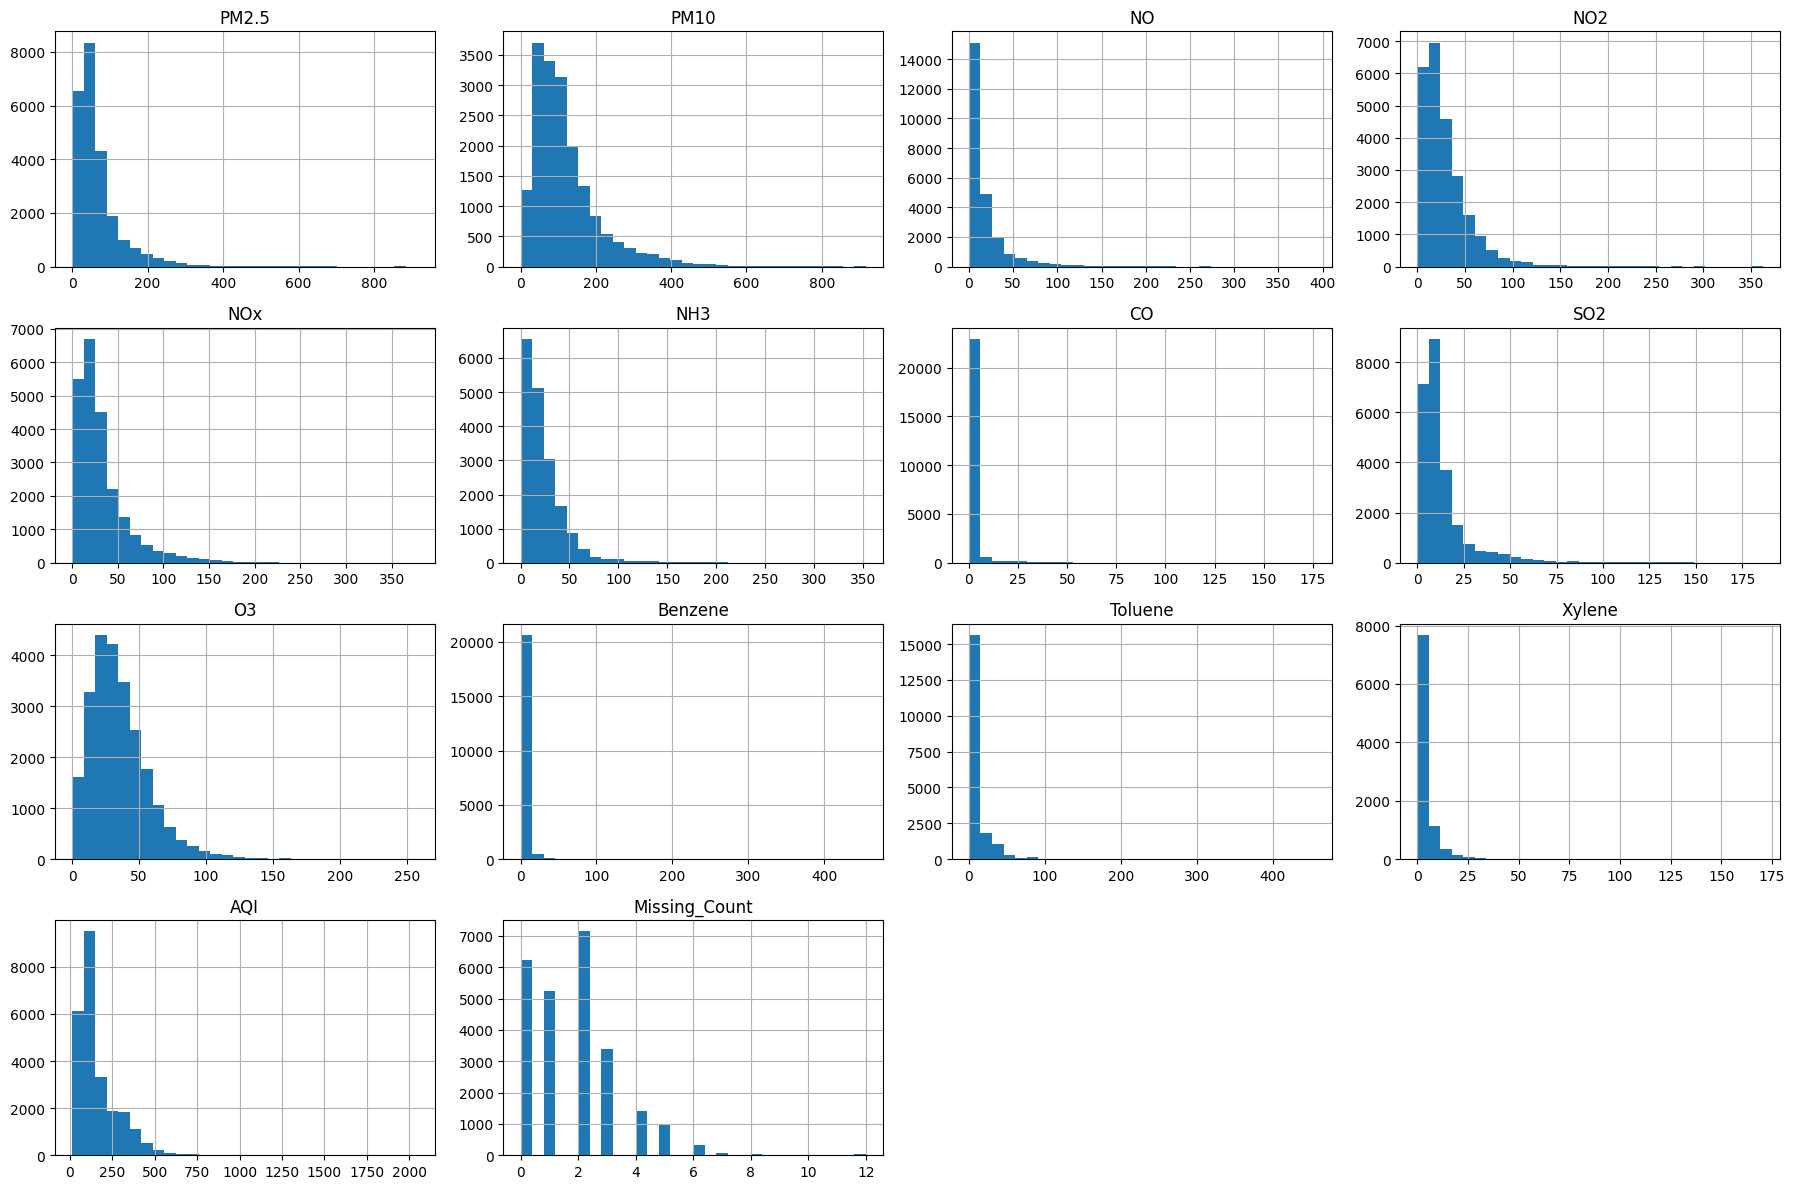

In [50]:
# Histograms for all numerical values

num_cols = df.select_dtypes(include='number').columns

df[num_cols].hist(
    figsize=(18,12),
    bins=30
)

plt.tight_layout()
plt.show()

In [51]:
# unique cities
df['City'].nunique()

26

In [52]:
# checking total counts per city
df['City'].value_counts()

,count
City,
Delhi,1999
Bengaluru,1910
Lucknow,1893
Chennai,1884
Hyderabad,1880
Patna,1459
Gurugram,1453
Ahmedabad,1334
Visakhapatnam,1171


In [53]:
df['AQI_Bucket'].value_counts()

,count
AQI_Bucket,
Moderate,8829
Satisfactory,8224
Poor,2781
Very Poor,2337
Good,1341
Severe,1338


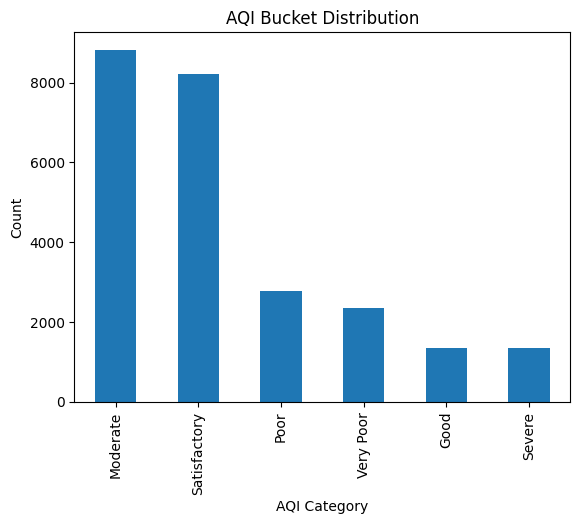

In [54]:
import matplotlib.pyplot as plt

df['AQI_Bucket'].value_counts().plot(kind='bar')

plt.title('AQI Bucket Distribution')
plt.xlabel('AQI Category')
plt.ylabel('Count')

plt.show()

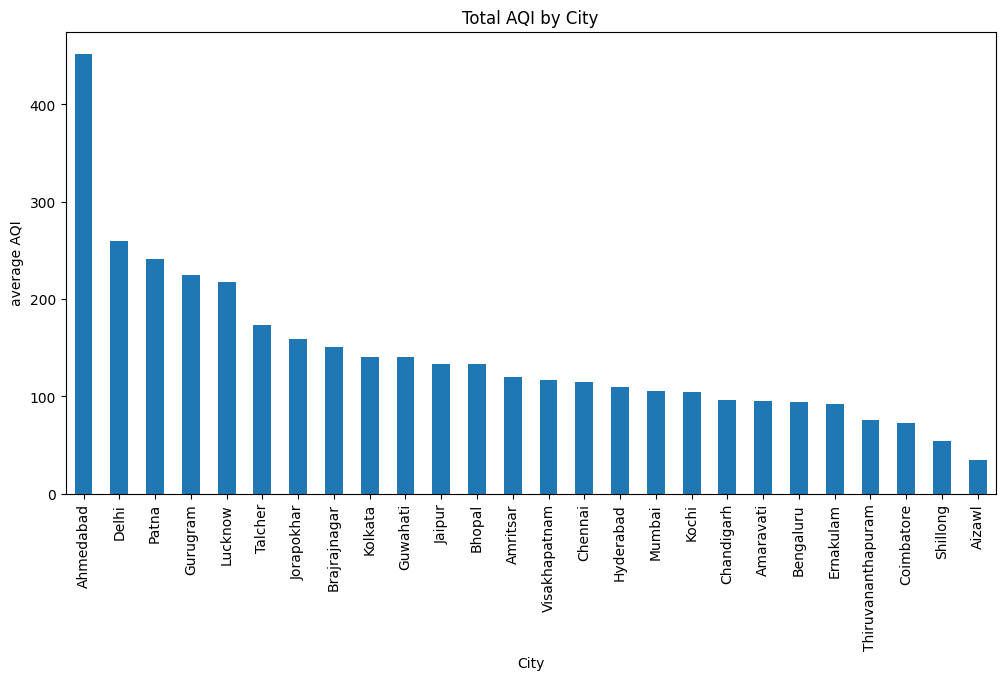

In [60]:
city_aqi_total = df.groupby('City')['AQI'].mean().sort_values(ascending=False)

city_aqi_total.plot(kind='bar', figsize=(12,6))
plt.title('Total AQI by City')
plt.ylabel('average AQI')
plt.xlabel('City')
plt.xticks(rotation=90)
plt.show()

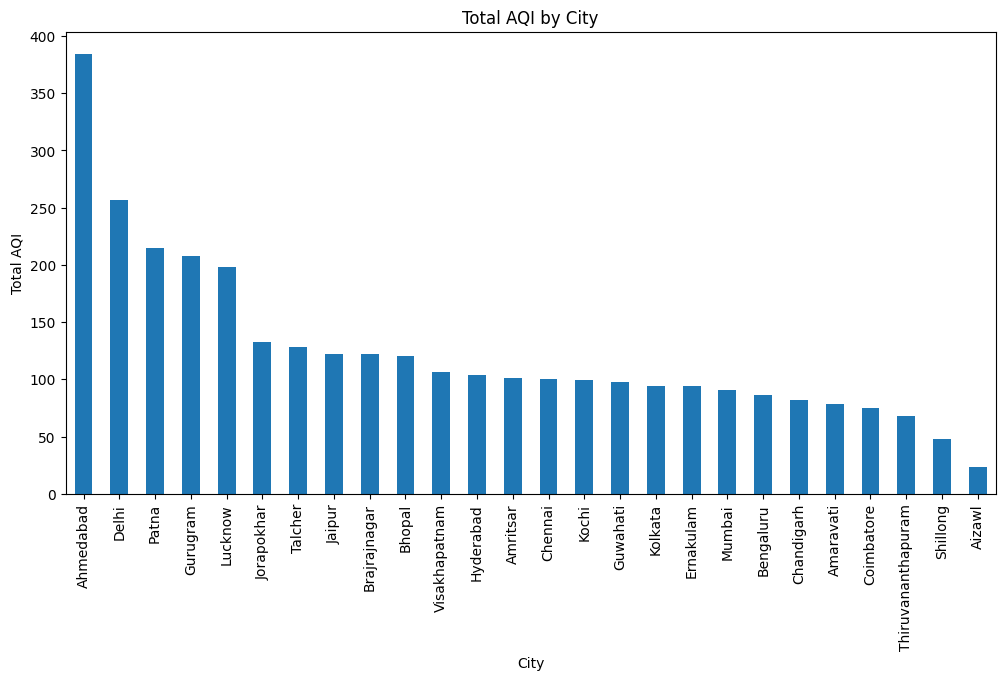

In [61]:
city_aqi_total = df.groupby('City')['AQI'].median().sort_values(ascending=False)

city_aqi_total.plot(kind='bar', figsize=(12,6))
plt.title('Total AQI by City')
plt.ylabel('Total AQI')
plt.xlabel('City')
plt.xticks(rotation=90)
plt.show()

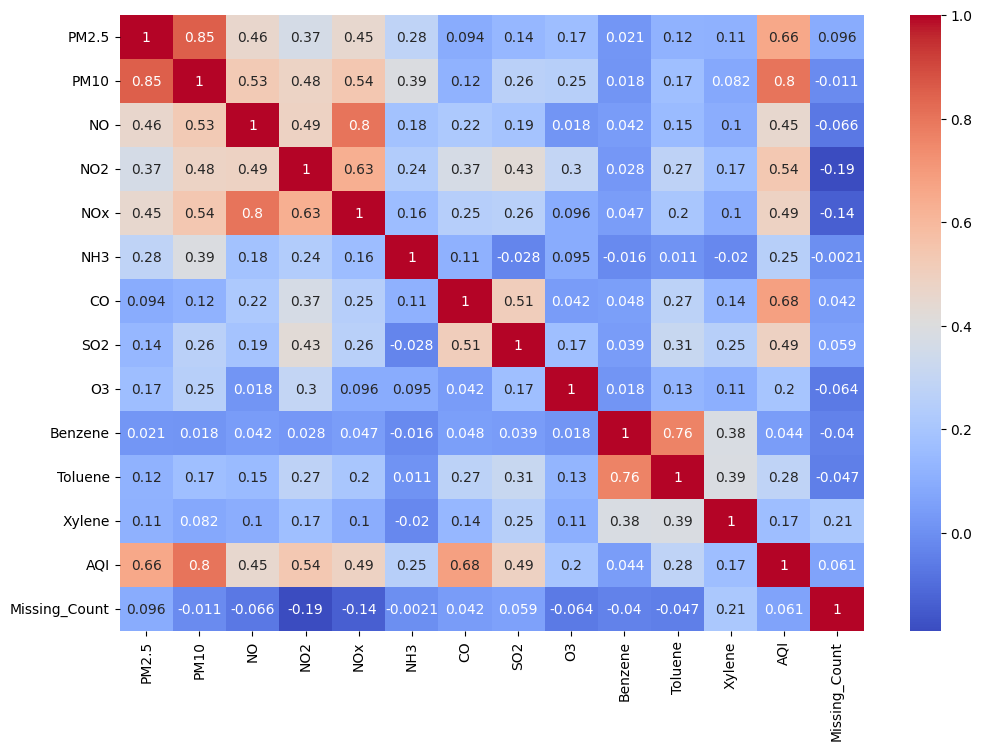

In [63]:
# Correlation Analysis
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [103]:
df.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [67]:
# since PM10 ~ AQI (0.8 correlation) we will carryout a regression analysis to predict the missing values of PM10
from sklearn.linear_model import LinearRegression

train = df[df['PM10'].notna()]
test = df[df['PM10'].isna()]

model = LinearRegression()
model.fit(train[['AQI']], train['PM10'])

df.loc[df['PM10'].isna(), 'PM10'] = model.predict(test[['AQI']])

In [92]:
# since PM10 ~ PM2.5 (0.8 correlation) we will carryout a regression analysis to predict the missing values of PM2.5
from sklearn.linear_model import LinearRegression

train = df[df['PM2.5'].notna()]
test = df[df['PM2.5'].isna()]

model = LinearRegression()
model.fit(train[['PM10']], train['PM2.5'])

df.loc[df['PM2.5'].isna(), 'PM2.5'] = model.predict(test[['PM10']])

In [88]:
# to fill No and NOx we will use city-wise median imputation
df['NO'] = df['NO'].fillna(df.groupby('City')['NO'].transform('median'))
df['NO'] = df['NO'].fillna(df['NO'].median())

df['NOx'] = df['NOx'].fillna(df.groupby('City')['NOx'].transform('median'))
df['NOx'] = df['NOx'].fillna(df['NOx'].median())

/tmp/ipykernel_1917/3887344668.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NO'] = df['NO'].fillna(df.groupby('City')['NO'].transform('median'))
/tmp/ipykernel_1917/3887344668.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NO'] = df['NO'].fillna(df['NO'].median())
/tmp/ipykernel_1917/3887344668.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [90]:
df['NO2'] = df['NO2'].fillna(df.groupby('City')['NO2'].transform('median'))
df['NO2'] = df['NO2'].fillna(df['NO2'].median())

/tmp/ipykernel_1917/534731656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NO2'] = df['NO2'].fillna(df.groupby('City')['NO2'].transform('median'))
/tmp/ipykernel_1917/534731656.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['NO2'] = df['NO2'].fillna(df['NO2'].median())


In [94]:
# for other remaining features we will use median
cols = ['CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'NH3']

for col in cols:
    df[col] = df[col].fillna(df.groupby('City')[col].transform('median'))

/tmp/ipykernel_1917/3252440986.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df.groupby('City')[col].transform('median'))
/tmp/ipykernel_1917/3252440986.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df.groupby('City')[col].transform('median'))
/tmp/ipykernel_1917/3252440986.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in t

In [95]:
# to Handle Xylene because it is too sparse, we will simply drop it entirely because above 60% missing makes imputation unreliable
df = df.drop(columns=['Xylene'])

In [100]:
cols = ['NH3', 'O3', 'Benzene', 'Toluene']

# 1. city-wise median
df[cols] = df[cols].fillna(df.groupby('City')[cols].transform('median'))

In [101]:
df = df.sort_values(['City', 'Date'])

df[cols] = df.groupby('City')[cols].transform(lambda x: x.interpolate())

In [102]:
# 2. time interpolation
df = df.sort_values(['City', 'Date'])
df[cols] = df.groupby('City')[cols].transform(lambda x: x.interpolate())

# 3. final fallback
df[cols] = df[cols].fillna(df[cols].median())

In [105]:
df = df.drop(columns=['Missing_Count'])

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,Missing_Count
28,Ahmedabad,2015-01-29,83.13,165.833453,33.72,33.72,33.72,17.055,6.93,49.52,59.76,0.020,0.000,209.0,Poor,2
29,Ahmedabad,2015-01-30,79.84,248.475195,41.08,41.08,41.08,17.055,13.85,48.49,97.07,0.040,0.000,328.0,Very Poor,2
30,Ahmedabad,2015-01-31,94.52,377.646321,52.61,52.61,52.61,17.055,24.39,67.39,111.33,0.240,0.010,514.0,Severe,2
31,Ahmedabad,2015-02-01,135.99,563.763858,84.57,84.57,84.57,17.055,43.48,75.23,102.70,0.400,0.040,782.0,Severe,2
32,Ahmedabad,2015-02-02,178.33,655.433690,72.80,72.80,72.80,17.055,54.56,55.04,107.38,0.460,0.060,914.0,Severe,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.940000,19.54,19.54,19.54,12.470,0.47,8.55,23.30,2.240,12.070,41.0,Good,0
29527,Visakhapatnam,2020-06-28,24.38,74.090000,16.53,16.53,16.53,11.990,0.52,12.72,30.14,0.740,2.210,70.0,Satisfactory,0
29528,Visakhapatnam,2020-06-29,22.91,65.730000,18.33,18.33,18.33,10.710,0.48,8.42,30.96,0.010,0.010,68.0,Satisfactory,0
29529,Visakhapatnam,2020-06-30,16.64,49.970000,18.80,18.80,18.80,10.030,0.52,9.84,28.30,0.000,0.000,54.0,Satisfactory,0


In [106]:
df = df.drop(columns=['Missing_Count'])

In [114]:
df.to_excel("pre-processed_city_day.xlsx", index=False)

In [113]:
df['Benzene'].describe()
# df['Toluene'].describe()

,Benzene
count,24850.000000
mean,3.211917
std,14.862802
min,0.010000
25%,0.550000
50%,1.220000
75%,3.010000
max,455.030000


In [109]:
import numpy as np

cols = ['Benzene', 'Toluene']

df[cols] = df[cols].replace(0, np.nan)

In [110]:
df[cols] = df[cols].fillna(df.groupby('City')[cols].transform('median'))

In [111]:
df = df.sort_values(['City', 'Date'])

df[cols] = df.groupby('City')[cols].transform(lambda x: x.interpolate())

In [120]:
import matplotlib
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:",matplotlib.__version__)
print("seaborn:",sns.__version__)

pandas: 2.2.2
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
